# Comparing Sparse & Dense Experimental Runs
Author: Dhruv Sharma (SLAC National Accelerator Lab, University of Illinois at Urbana-Champaign)

The experimental runs taken contain data of electrons hitting the ePix detector after passing through a UV polarizer, which was gradually turned over the course of the run to lower the number of electrons that hit the surface. As a result, earlier events are considered in the dense electron regime and later ones in the sparse electron regime. This notebook compares the two regimes across a few runs/gain modes

### 0. Import Statements

In [59]:
import uproot
import matplotlib.pyplot as plt
import numpy as np
import mplhep as mplhep
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

### 1. Useful Methods

These methods pull data in the `catalogs/` folder generated by the `Get_Exp_Data.ipynb` notebook, also located in this directory.

In [60]:
def get_hist_mean(hist):
    counts, edges = hist[0], hist[1]
    bin_centers = (edges[:-1] + edges[1:]) / 2
    mean = np.average(bin_centers, weights=counts)
    return mean

def get_exp_data(run, is_sparse):
    if (is_sparse):
        exp_py = np.load('catalog/Intensity_evts_run_'+str(run)+'_sparse.npy')
    else:
        exp_py = np.load('catalog/Intensity_evts_run_'+str(run)+'_dense.npy')
    bins_intn=np.arange(80,1000,5)
    all_counts = []
    for i_mdl in range(4):
        hist_intn, bin_edges = np.histogram(exp_py[:,i_mdl,:].flatten(), bins=bins_intn)
        all_counts.append(hist_intn)
    exp_counts = np.mean(np.array(all_counts), axis=0)
    return exp_counts

### 2. Compare Sparse/Dense Experimental Data

In [61]:
runs = [126, 115, 153, 491]
sparse_exp_data = [get_exp_data(run, True) for run in runs]
dense_exp_data = [get_exp_data(run, False) for run in runs]

bins = np.linspace(80,995,184)[:-1]

scales = [max(sparse_exp_data[i]) / max(dense_exp_data[i]) for i in range(4)]
exp_peak_keVs = [bins[np.argmax(sparse_exp_data[i])] for i in range(4)]

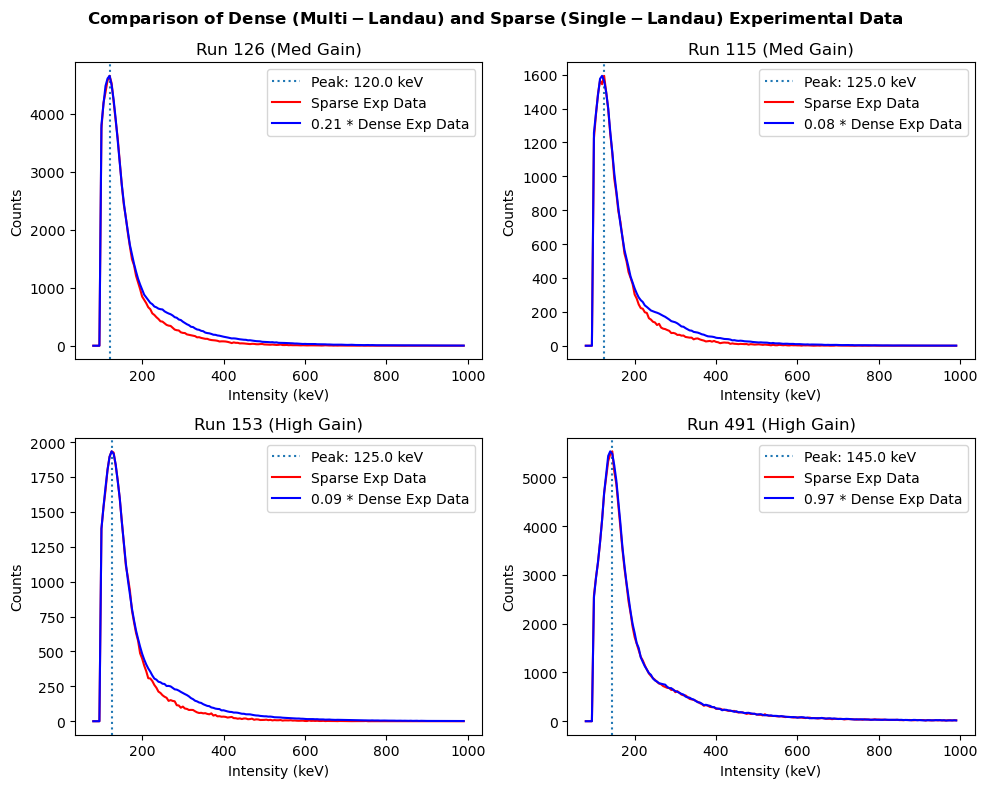

In [62]:
fig,ax = plt.subplots(2,2,figsize=(10,8))
ax = ax.flatten()
plt.suptitle(r'$\bf{Comparison\ of\ Dense\ (Multi-Landau)\ and\ Sparse\ (Single-Landau)\ Experimental\ Data\ }$')

for i,run in enumerate(runs):
    gain="Med" if i < 2 else "High"
    ax[i].set_title(f"Run {run} ({gain} Gain)")
    ax[i].set_xlabel("Intensity (keV)")
    ax[i].set_ylabel("Counts")
    ax[i].axvline(exp_peak_keVs[i],linestyle='dotted',label=f'Peak: {exp_peak_keVs[i]} keV')
    ax[i].plot(bins,sparse_exp_data[i],color='red',label=f'Sparse Exp Data')
    ax[i].plot(bins, scales[i] * dense_exp_data[i],color='blue',label=f'{scales[i]:.2f} * Dense Exp Data')
    ax[i].legend()

plt.tight_layout()

### 3. Compare Sparse Simulations/Experimental Data

In [88]:
sparse_sim_data=np.zeros(500)
sparse_sim_bins = np.linspace(0,1,501) * 1000
num_jobs = 20
num_elecs = 4000 # increments of 2000
for i in range(1,num_jobs + 1):
    sparse_sim_file = uproot.open(f"/sdf/home/d/dhruvshr/SULI2026/ePix_Simulation/Examples/PixelSim_ePix_Data_Gen/outputs/sim_{num_elecs}_e-_run_{i:03d}.root")
    sparse_sim_data += sparse_sim_file["TotalEdep"].to_numpy()[0]

In [89]:
sim_scales = [max(sparse_exp_data[i]) / max(sparse_sim_data) for i in range(4)]
sim_peak = sparse_sim_bins[np.argmax(sparse_sim_data)]
num_elecs = int(np.sum(sparse_sim_file['EntryMap'].to_numpy()[0]))

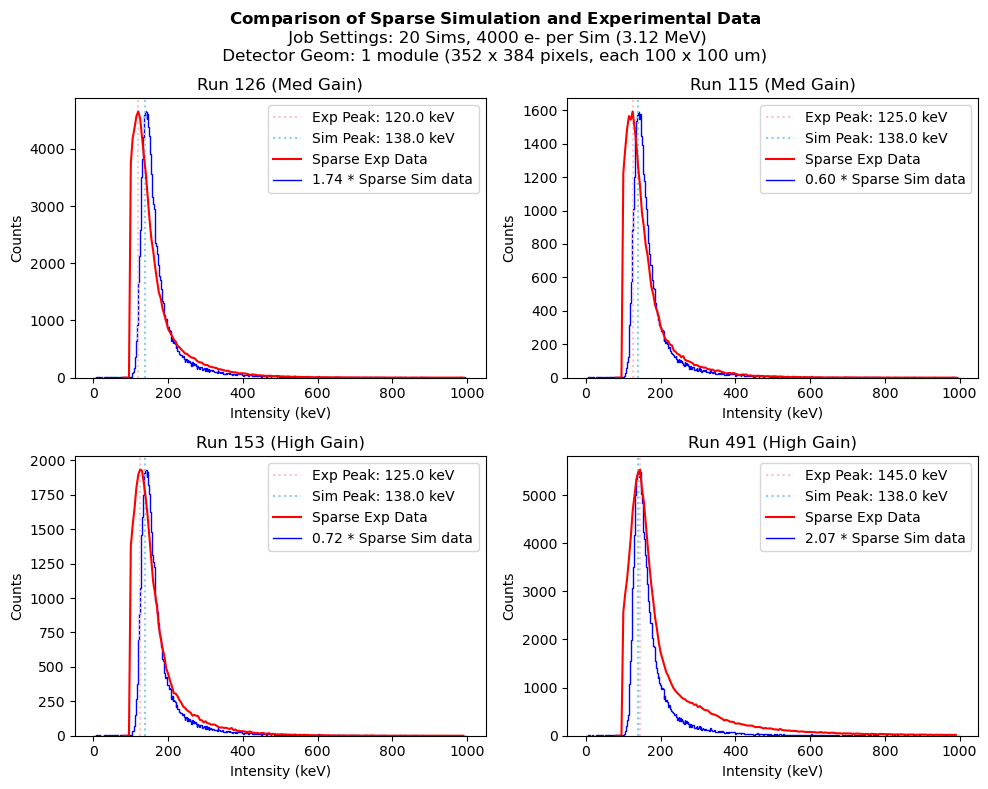

In [90]:
fig,ax = plt.subplots(2,2,figsize=(10,8))
ax = ax.flatten()
bins = np.linspace(80,995,184)[:-1]
plt.suptitle(r'$\bf{Comparison\ of\ Sparse\ Simulation\ and\ Experimental\ Data\ }$' +
            f'\n Job Settings: {num_jobs} Sims, {num_elecs} e- per Sim (3.12 MeV)' +
            f'\n Detector Geom: 1 module (352 x 384 pixels, each 100 x 100 um) ')

for i,run in enumerate(runs):
    gain="Med" if i < 2 else "High"
    ax[i].set_title(f"Run {run} ({gain} Gain)")
    ax[i].set_xlabel("Intensity (keV)")
    ax[i].set_ylabel("Counts")
    ax[i].axvline(exp_peak_keVs[i],linestyle='dotted',color='pink',label=f'Exp Peak: {exp_peak_keVs[i]} keV')
    ax[i].axvline(sim_peak,linestyle='dotted',color='skyblue',label=f'Sim Peak: {sim_peak} keV')
    ax[i].plot(bins,sparse_exp_data[i],color='red',label='Sparse Exp Data')
    ax[i].stairs(sim_scales[i] * sparse_sim_data,sparse_sim_bins,color='blue',label=f'{sim_scales[i]:.2f} * Sparse Sim data')
    ax[i].legend()

plt.tight_layout()

### 4. Sparse Simulation vs Experimental Data Curve Fitting

#### 4.1. Shifted Simulation Data

The first step can be simply translating the simulation data left to match the experimental data peak

In [91]:
shifts = [sim_peak - exp_peak_keVs[i] + 10 for i in range(4)]
shifts[3] += 7

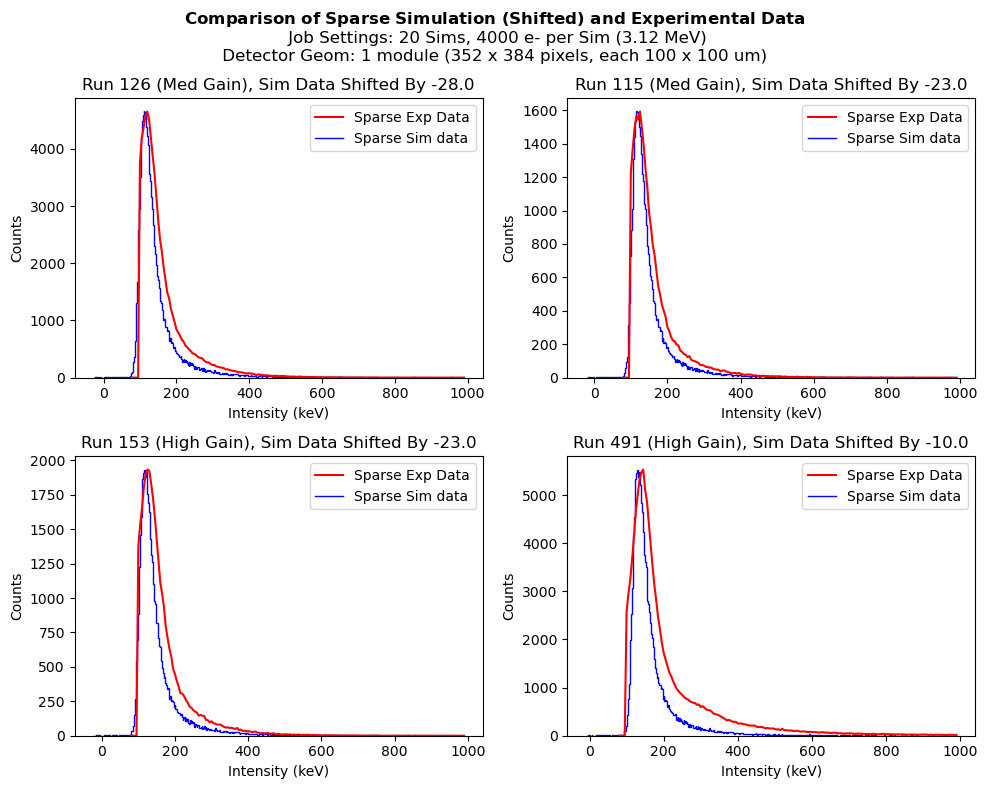

In [92]:
fig,ax = plt.subplots(2,2,figsize=(10,8))
ax = ax.flatten()
bins = np.linspace(80,995,184)[:-1]
plt.suptitle(r'$\bf{Comparison\ of\ Sparse\ Simulation\ (Shifted)\ and\ Experimental\ Data\ }$' +
            f'\n Job Settings: {num_jobs} Sims, {num_elecs} e- per Sim (3.12 MeV)' +
            f'\n Detector Geom: 1 module (352 x 384 pixels, each 100 x 100 um) ')

for i,run in enumerate(runs):
    gain="Med" if i < 2 else "High"
    ax[i].set_title(f"Run {run} ({gain} Gain), Sim Data Shifted By {-1 * shifts[i]}")
    ax[i].set_xlabel("Intensity (keV)")
    ax[i].set_ylabel("Counts")
    ax[i].plot(bins,sparse_exp_data[i],color='red',label=f'Sparse Exp Data')
    ax[i].stairs(sim_scales[i] * sparse_sim_data,sparse_sim_bins-shifts[i],color='blue',label=f'Sparse Sim data')
    ax[i].legend()

plt.tight_layout()

#### 4.2. Shifted + Convolved Simulation Data

Now we'll try fitting with consideration for the detector resolution by convolving with a Gaussian

bins=np.linspace(0,1000,201)
counts_sparse,_ = np.histogram(sparse_sim_data, bins)
bin_width = bins[1]-bins[0]
sigma_bins = 10 / bin_width

conv_sparse_data = gaussian_filter1d(counts_sparse.astype(float), sigma_bins, mode='constant',cval=0)

In [93]:
detector_noise = 20
sigma_bins = detector_noise / (sparse_sim_bins[1] - sparse_sim_bins[0])  # use the actual bin width of sparse_sim_bins
conv_sparse_data = gaussian_filter1d(sparse_sim_data.astype(float), sigma_bins, mode='constant', cval=0)

In [94]:
conv_scales = [max(sparse_exp_data[i]) / max(conv_sparse_data) for i in range(4)]

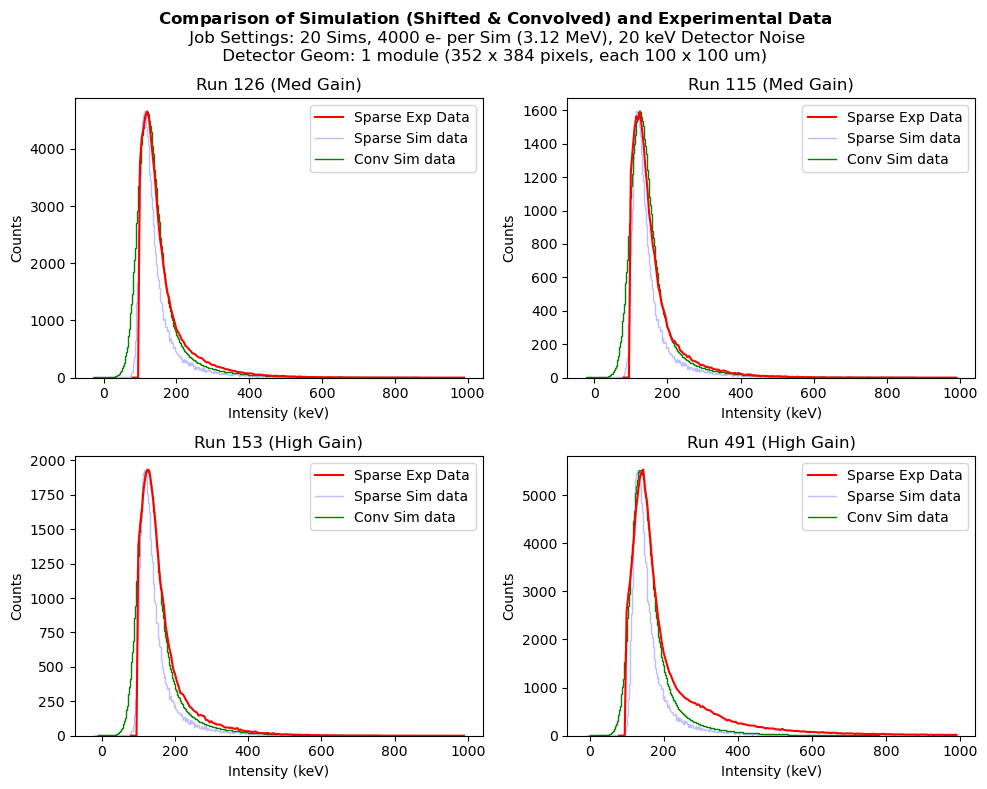

In [96]:
fig,ax = plt.subplots(2,2,figsize=(10,8))
ax = ax.flatten()
plt.suptitle(r'$\bf{Comparison\ of\ Simulation\ (Shifted\ &\ Convolved)\ and\ Experimental\ Data\ }$' +
            f'\n Job Settings: {num_jobs} Sims, {num_elecs} e- per Sim (3.12 MeV), {detector_noise} keV Detector Noise' +
            f'\n Detector Geom: 1 module (352 x 384 pixels, each 100 x 100 um) ')

peak_scale = max(conv_sparse_data) / max(sparse_sim_data)

for i,run in enumerate(runs):
    gain="Med" if i < 2 else "High"
    ax[i].set_title(f"Run {run} ({gain} Gain), Sim Data Shifted By {-1 * shifts[i]}")
    ax[i].set_xlabel("Intensity (keV)")
    ax[i].set_ylabel("Counts")
    ax[i].plot(bins,sparse_exp_data[i],color='red',label='Sparse Exp Data')
    ax[i].stairs(sim_scales[i] * sparse_sim_data,sparse_sim_bins-shifts[i],color='blue',label='Sparse Sim data',alpha=0.25)
    ax[i].stairs(conv_scales[i] * conv_sparse_data, sparse_sim_bins-shifts[i], color='green', label='Conv Sim data')
    ax[i].legend()

plt.tight_layout()